In [1]:
# ============================================================
# CAPSTONE PROJECT
# Fuel Economy Analysis & Machine Learning (2008–2018)
# Block 1 : Project Setup
# ============================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# Import Required Libraries
# ============================================================

# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Display Settings
# ============================================================

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 1000)

# Plot Style
plt.style.use("ggplot")

# Random Seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("="*60)
print(" Fuel Economy Capstone Project ")
print("="*60)
print("Libraries Imported Successfully")
print("Random State :", RANDOM_STATE)
print("="*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Fuel Economy Capstone Project 
Libraries Imported Successfully
Random State : 42


In [2]:
# ============================================================
# Block 2 : Load All EPA Green Vehicle Datasets (2008-2018)
# ============================================================

import os

# Project Data Folder
DATA_PATH = "/content/drive/MyDrive/FuelEconomyProject/data"

# Dictionary to store all datasets
datasets = {}

# File names for each year
file_names = {
    2008: "all_alpha_08.xls",
    2009: "all_alpha_09.xls",
    2010: "all_alpha_10.xls",
    2011: "all_alpha_11.xlsx",
    2012: "all_alpha_12.xlsx",
    2013: "all_alpha_13.xlsx",
    2014: "all_alpha_14.xlsx",
    2015: "all_alpha_15.xlsx",
    2016: "all_alpha_16.xlsx",
    2017: "all_alpha_17.xlsx",
    2018: "all_alpha_18.xlsx"
}

print("=" * 70)
print("Loading EPA Green Vehicle Datasets")
print("=" * 70)

for year, filename in file_names.items():

    filepath = os.path.join(DATA_PATH, filename)

    try:
        df = pd.read_excel(filepath)

        datasets[year] = df

        print(f"✅ {year} : Loaded Successfully | Shape = {df.shape}")

    except Exception as e:

        print(f"❌ {year} : Error")
        print(e)

print("=" * 70)
print(f"Total Datasets Loaded : {len(datasets)}")
print("=" * 70)

Loading EPA Green Vehicle Datasets
✅ 2008 : Loaded Successfully | Shape = (2404, 18)
✅ 2009 : Loaded Successfully | Shape = (2561, 17)
✅ 2010 : Loaded Successfully | Shape = (2326, 17)
✅ 2011 : Loaded Successfully | Shape = (2171, 17)
✅ 2012 : Loaded Successfully | Shape = (2252, 17)
✅ 2013 : Loaded Successfully | Shape = (2397, 18)
✅ 2014 : Loaded Successfully | Shape = (2517, 18)
✅ 2015 : Loaded Successfully | Shape = (2653, 18)
✅ 2016 : Loaded Successfully | Shape = (2589, 18)
✅ 2017 : Loaded Successfully | Shape = (2589, 18)
✅ 2018 : Loaded Successfully | Shape = (2713, 18)
Total Datasets Loaded : 11


In [3]:
# ============================================================
# Block 3 : Dataset Overview
# Problem 1
# ============================================================

summary = []

for year, df in datasets.items():

    summary.append({
        "Year": year,
        "Rows (Samples)": df.shape[0],
        "Columns": df.shape[1]
    })

summary_df = pd.DataFrame(summary)

summary_df = summary_df.sort_values("Year").reset_index(drop=True)

print("="*65)
print("DATASET OVERVIEW")
print("="*65)

display(summary_df)

DATASET OVERVIEW


,Year,Rows (Samples),Columns
0,2008,2404,18
1,2009,2561,17
2,2010,2326,17
3,2011,2171,17
4,2012,2252,17
5,2013,2397,18
6,2014,2517,18
7,2015,2653,18
8,2016,2589,18
9,2017,2589,18


In [4]:
# ============================================================
# Block 4 : Duplicate Rows Analysis
# Problem 1
# ============================================================

duplicate_summary = []

print("=" * 75)
print("DUPLICATE ROWS ANALYSIS")
print("=" * 75)

for year, df in datasets.items():

    duplicate_count = df.duplicated().sum()

    duplicate_summary.append({
        "Year": year,
        "Total Rows": len(df),
        "Duplicate Rows": duplicate_count,
        "Duplicate (%)": round((duplicate_count / len(df)) * 100, 2)
    })

duplicate_df = pd.DataFrame(duplicate_summary)

display(duplicate_df)

print("\n" + "=" * 75)

total_duplicates = duplicate_df["Duplicate Rows"].sum()

print(f"Total Duplicate Rows Across All Datasets : {total_duplicates}")

print("=" * 75)

DUPLICATE ROWS ANALYSIS


,Year,Total Rows,Duplicate Rows,Duplicate (%)
0,2008,2404,25,1.04
1,2009,2561,43,1.68
2,2010,2326,28,1.20
3,2011,2171,30,1.38
4,2012,2252,40,1.78
5,2013,2397,27,1.13
6,2014,2517,22,0.87
7,2015,2653,38,1.43
8,2016,2589,0,0.00
9,2017,2589,0,0.00



Total Duplicate Rows Across All Datasets : 253


In [5]:
# ============================================================
# Block 5 : Compare Column Names Across Years
# ============================================================

print("=" * 80)
print("COLUMN COMPARISON ACROSS ALL DATASETS")
print("=" * 80)

for year, df in datasets.items():
    print(f"\n📅 {year} ({len(df.columns)} Columns)")
    print("-" * 80)

    for i, col in enumerate(df.columns, start=1):
        print(f"{i:2d}. {col}")

print("\n" + "=" * 80)

COLUMN COMPARISON ACROSS ALL DATASETS

📅 2008 (18 Columns)
--------------------------------------------------------------------------------
 1. Model
 2. Displ
 3. Cyl
 4. Trans
 5. Drive
 6. Fuel
 7. Sales Area
 8. Stnd
 9. Underhood ID
10. Veh Class
11. Air Pollution Score
12. FE Calc Appr
13. City MPG
14. Hwy MPG
15. Cmb MPG
16. Unadj Cmb MPG
17. Greenhouse Gas Score
18. SmartWay

📅 2009 (17 Columns)
--------------------------------------------------------------------------------
 1. Model
 2. Displ
 3. Cyl
 4. Trans
 5. Drive
 6. Fuel
 7. Sales Area
 8. Stnd
 9. Stnd Description
10. Underhood ID
11. Veh Class
12. Air Pollution Score
13. City MPG
14. Hwy MPG
15. Cmb MPG
16. Greenhouse Gas Score
17. SmartWay

📅 2010 (17 Columns)
--------------------------------------------------------------------------------
 1. Model
 2. Displ
 3. Cyl
 4. Trans
 5. Drive
 6. Fuel
 7. Sales Area
 8. Stnd
 9. Stnd Description
10. Underhood ID
11. Veh Class
12. Air Pollution Score
13. City MPG
14. Hwy 

In [6]:
# ============================================================
# Block 6 : Data Types Analysis
# Problem 1
# ============================================================

print("=" * 80)
print("DATA TYPES ANALYSIS")
print("=" * 80)

datatype_summary = []

for year, df in datasets.items():

    print(f"\n📅 {year}")
    print("-" * 80)

    temp = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values
    })

    display(temp)

    datatype_summary.append({
        "Year": year,
        "Object Columns": (df.dtypes == "object").sum(),
        "Numeric Columns": (df.dtypes != "object").sum()
    })

print("\n")
print("=" * 80)
print("SUMMARY")
print("=" * 80)

datatype_summary = pd.DataFrame(datatype_summary)

display(datatype_summary)

DATA TYPES ANALYSIS

📅 2008
--------------------------------------------------------------------------------


,Column,Data Type
0,Model,object
1,Displ,float64
2,Cyl,object
3,Trans,object
4,Drive,object
5,Fuel,object
6,Sales Area,object
7,Stnd,object
8,Underhood ID,object
9,Veh Class,object



📅 2009
--------------------------------------------------------------------------------


,Column,Data Type
0,Model,object
1,Displ,float64
2,Cyl,float64
3,Trans,object
4,Drive,object
5,Fuel,object
6,Sales Area,object
7,Stnd,object
8,Stnd Description,object
9,Underhood ID,object



📅 2010
--------------------------------------------------------------------------------


...

,Column,Data Type
0,Model,object
1,Displ,float64
2,Cyl,float64
3,Trans,object
4,Drive,object
5,Fuel,object
6,Cert Region,object
7,Stnd,object
8,Stnd Description,object
9,Underhood ID,object



📅 2018
--------------------------------------------------------------------------------


,Column,Data Type
0,Model,object
1,Displ,float64
2,Cyl,float64
3,Trans,object
4,Drive,object
5,Fuel,object
6,Cert Region,object
7,Stnd,object
8,Stnd Description,object
9,Underhood ID,object




SUMMARY


,Year,Object Columns,Numeric Columns
0,2008,16,2
1,2009,15,2
2,2010,15,2
3,2011,15,2
4,2012,15,2
5,2013,16,2
6,2014,16,2
7,2015,16,2
8,2016,16,2
9,2017,14,4


In [7]:
# ============================================================
# Block 7 : Missing Values Analysis
# Problem 1
# ============================================================

print("=" * 90)
print("MISSING VALUES ANALYSIS")
print("=" * 90)

missing_summary = []

for year, df in datasets.items():

    print(f"\n📅 Dataset : {year}")
    print("-" * 90)

    # Missing values per column
    missing = df.isnull().sum()

    # Keep only columns having missing values
    missing = missing[missing > 0]

    if len(missing) == 0:
        print("✅ No Missing Values Found")

    else:
        temp = pd.DataFrame({
            "Column": missing.index,
            "Missing Values": missing.values,
            "Missing (%)": np.round((missing.values / len(df)) * 100, 2)
        })

        display(temp)

    # Store summary
    missing_summary.append({
        "Year": year,
        "Columns with Missing Values": len(missing),
        "Total Missing Values": df.isnull().sum().sum()
    })

print("\n")
print("=" * 90)
print("SUMMARY")
print("=" * 90)

missing_summary = pd.DataFrame(missing_summary)

display(missing_summary)

MISSING VALUES ANALYSIS

📅 Dataset : 2008
------------------------------------------------------------------------------------------


,Column,Missing Values,Missing (%)
0,Cyl,199,8.28
1,Trans,199,8.28
2,Drive,93,3.87
3,FE Calc Appr,199,8.28
4,City MPG,199,8.28
5,Hwy MPG,199,8.28
6,Cmb MPG,199,8.28
7,Unadj Cmb MPG,199,8.28
8,Greenhouse Gas Score,199,8.28



📅 Dataset : 2009
------------------------------------------------------------------------------------------


,Column,Missing Values,Missing (%)
0,Cyl,198,7.73
1,City MPG,198,7.73
2,Hwy MPG,198,7.73
3,Cmb MPG,198,7.73
4,Greenhouse Gas Score,198,7.73



📅 Dataset : 2010
------------------------------------------------------------------------------------------


...

,Column,Missing Values,Missing (%)
0,Displ,62,2.39
1,Cyl,62,2.39



📅 Dataset : 2018
------------------------------------------------------------------------------------------


,Column,Missing Values,Missing (%)
0,Displ,50,1.84
1,Cyl,50,1.84




SUMMARY


,Year,Columns with Missing Values,Total Missing Values
0,2008,9,1685
1,2009,5,990
2,2010,6,690
3,2011,6,590
4,2012,6,604
5,2013,7,885
6,2014,7,1045
7,2015,7,1404
8,2016,2,120
9,2017,2,124


In [8]:
# ============================================================
# Block 8A : Unique Values Summary
# Problem 1
# ============================================================

print("=" * 90)
print("UNIQUE VALUES SUMMARY")
print("=" * 90)

for year, df in datasets.items():

    print(f"\n📅 Dataset : {year}")
    print("-" * 90)

    unique_summary = pd.DataFrame({
        "Column": df.columns,
        "Non-Null Unique Values": [df[col].nunique(dropna=True) for col in df.columns]
    })

    display(unique_summary)

UNIQUE VALUES SUMMARY

📅 Dataset : 2008
------------------------------------------------------------------------------------------


,Column,Non-Null Unique Values
0,Model,436
1,Displ,47
2,Cyl,8
3,Trans,14
4,Drive,2
5,Fuel,5
6,Sales Area,3
7,Stnd,12
8,Underhood ID,343
9,Veh Class,9



📅 Dataset : 2009
------------------------------------------------------------------------------------------


,Column,Non-Null Unique Values
0,Model,473
1,Displ,47
2,Cyl,8
3,Trans,19
4,Drive,2
5,Fuel,5
6,Sales Area,3
7,Stnd,10
8,Stnd Description,14
9,Underhood ID,361



📅 Dataset : 2010
------------------------------------------------------------------------------------------


...

,Column,Non-Null Unique Values
0,Model,607
1,Displ,45
2,Cyl,8
3,Trans,25
4,Drive,2
5,Fuel,6
6,Cert Region,2
7,Stnd,26
8,Stnd Description,26
9,Underhood ID,392



📅 Dataset : 2017
------------------------------------------------------------------------------------------


,Column,Non-Null Unique Values
0,Model,634
1,Displ,44
2,Cyl,8
3,Trans,27
4,Drive,2
5,Fuel,7
6,Cert Region,2
7,Stnd,27
8,Stnd Description,27
9,Underhood ID,405



📅 Dataset : 2018
------------------------------------------------------------------------------------------


,Column,Non-Null Unique Values
0,Model,652
1,Displ,45
2,Cyl,9
3,Trans,29
4,Drive,2
5,Fuel,6
6,Cert Region,2
7,Stnd,25
8,Stnd Description,25
9,Underhood ID,422


In [9]:
# ============================================================
# Block 8B : Unique Values & Counts (Categorical Features)
# Problem 1
# ============================================================

categorical_columns = [
    "Fuel",
    "Drive",
    "Veh Class",
    "SmartWay"
]

for year, df in datasets.items():

    print("\n" + "=" * 90)
    print(f"DATASET : {year}")
    print("=" * 90)

    for col in categorical_columns:

        if col in df.columns:

            print(f"\n🔹 {col}")
            print("-" * 60)

            display(df[col].value_counts(dropna=False).to_frame(name="Count"))


DATASET : 2008

🔹 Fuel
------------------------------------------------------------


,Count
Fuel,
Gasoline,2318
ethanol/gas,72
diesel,11
CNG,2
ethanol,1



🔹 Drive
------------------------------------------------------------


,Count
Drive,
2WD,1525
4WD,786
NaN,93



🔹 Veh Class
------------------------------------------------------------


...

,Count
Drive,
2WD,1535
4WD,1178



🔹 Veh Class
------------------------------------------------------------


,Count
Veh Class,
small car,853
small SUV,467
midsize car,441
large car,278
standard SUV,278
pickup,216
station wagon,114
special purpose,38
minivan,23



🔹 SmartWay
------------------------------------------------------------


,Count
SmartWay,
No,2296
Yes,309
Elite,108


In [10]:
# ============================================================
# Block 9 : Grouping Analysis
# Problem 1
# ============================================================

print("="*100)
print("GROUPING ANALYSIS")
print("="*100)

# Columns that should behave as numeric during analysis
numeric_columns = [
    "City MPG",
    "Hwy MPG",
    "Cmb MPG",
    "Greenhouse Gas Score",
    "Air Pollution Score"
]

for year, df in datasets.items():

    print("\n")
    print("="*100)
    print(f"DATASET : {year}")
    print("="*100)

    # Copy dataset (original data will remain unchanged)
    temp = df.copy()

    # Convert numeric columns temporarily
    for col in numeric_columns:

        if col in temp.columns:
            temp[col] = pd.to_numeric(temp[col], errors="coerce")

    # --------------------------------------------------------
    # 1 Vehicle Class Analysis
    # --------------------------------------------------------

    if "Veh Class" in temp.columns and "City MPG" in temp.columns:

        print("\n1️⃣ Vehicle Class vs Average City MPG")

        vc = (
            temp.groupby("Veh Class")["City MPG"]
            .mean()
            .round(2)
            .sort_values(ascending=False)
            .reset_index()
        )

        display(vc)

    # --------------------------------------------------------
    # 2 Fuel Type Analysis
    # --------------------------------------------------------

    if "Fuel" in temp.columns and "Cmb MPG" in temp.columns:

        print("\n2️⃣ Fuel Type vs Average Combined MPG")

        fuel = (
            temp.groupby("Fuel")["Cmb MPG"]
            .mean()
            .round(2)
            .sort_values(ascending=False)
            .reset_index()
        )

        display(fuel)

    # --------------------------------------------------------
    # 3 SmartWay Analysis
    # --------------------------------------------------------

    if "SmartWay" in temp.columns and "Greenhouse Gas Score" in temp.columns:

        print("\n3️⃣ SmartWay vs Average Greenhouse Gas Score")

        smart = (
            temp.groupby("SmartWay")["Greenhouse Gas Score"]
            .mean()
            .round(2)
            .sort_values(ascending=False)
            .reset_index()
        )

        display(smart)

    # --------------------------------------------------------
    # 4 Drive Type Analysis
    # --------------------------------------------------------

    if "Drive" in temp.columns and "Cmb MPG" in temp.columns:

        print("\n4️⃣ Drive Type vs Average Combined MPG")

        drive = (
            temp.groupby("Drive")["Cmb MPG"]
            .mean()
            .round(2)
            .sort_values(ascending=False)
            .reset_index()
        )

        display(drive)

    # --------------------------------------------------------
    # 5 Fuel Distribution
    # --------------------------------------------------------

    if "Fuel" in temp.columns:

        print("\n5️⃣ Fuel Type Distribution")

        fuel_count = (
            temp["Fuel"]
            .value_counts()
            .reset_index()
        )

        fuel_count.columns = ["Fuel Type","Number of Vehicles"]

        display(fuel_count)

print("\n")
print("="*100)
print("✅ Problem 1 Completed Successfully")
print("="*100)

GROUPING ANALYSIS


DATASET : 2008

1️⃣ Vehicle Class vs Average City MPG


,Veh Class,City MPG
0,station wagon,19.61
1,midsize car,18.62
2,small car,18.34
3,minivan,16.71
4,SUV,16.38
5,large car,15.70
6,pickup,14.93
7,van,13.00
8,special purpose,NaN



2️⃣ Fuel Type vs Average Combined MPG


,Fuel,Cmb MPG
0,CNG,28.00
1,diesel,20.57
2,Gasoline,19.59
3,ethanol,13.00
4,ethanol/gas,NaN



3️⃣ SmartWay vs Average Greenhouse Gas Score


...


4️⃣ Drive Type vs Average Combined MPG


,Drive,Cmb MPG
0,2WD,27.03
1,4WD,22.90



5️⃣ Fuel Type Distribution


,Fuel Type,Number of Vehicles
0,Gasoline,2425
1,Ethanol/Gas,94
2,Diesel,74
3,Gasoline/Electricity,70
4,Electricity,46
5,Hydrogen,4




✅ Problem 1 Completed Successfully


PROBLEM 2 - ALTERNATIVE FUEL VEHICLES ANALYSIS


,Year,Unique Alternative Fuel Models
0,2008,43
1,2009,55
2,2010,73
3,2011,105
4,2012,110
5,2013,123
6,2014,140
7,2015,142
8,2016,92
9,2017,97


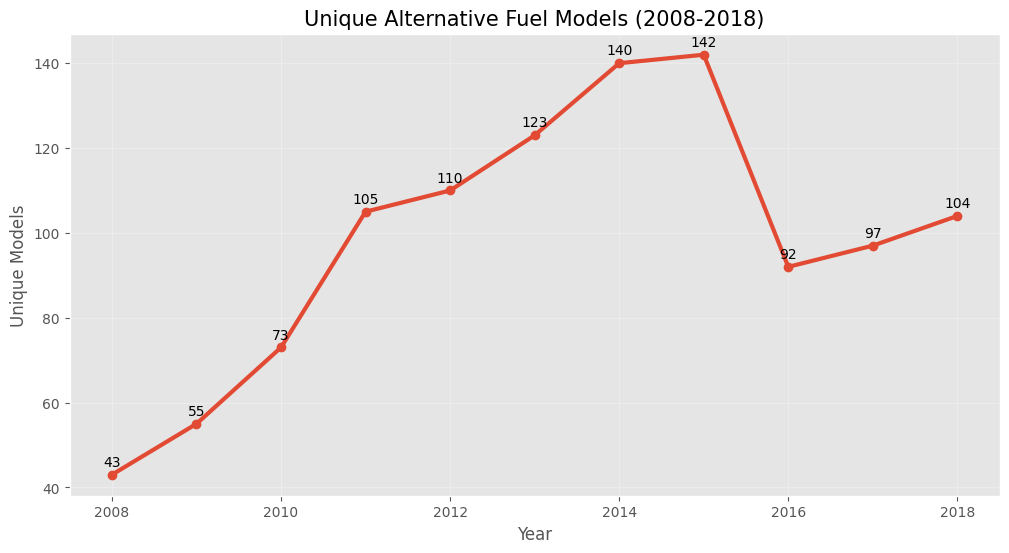


Conclusion
----------------------------------------
2008 : 43 models
2018 : 104 models
Increase : 61 models


In [11]:
# ============================================================
# BLOCK 9A
# Alternative Fuel Vehicles Trend (2008-2018)
# ============================================================

import matplotlib.pyplot as plt

print("="*90)
print("PROBLEM 2 - ALTERNATIVE FUEL VEHICLES ANALYSIS")
print("="*90)

alternative_counts = []

for year, df in datasets.items():

    temp = df.copy()

    # Fuel names ko standardize karo
    temp["Fuel"] = temp["Fuel"].astype(str).str.strip().str.lower()

    # Sirf gasoline remove karna hai
    alt = temp[temp["Fuel"] != "gasoline"]

    unique_models = alt["Model"].nunique()

    alternative_counts.append({
        "Year": year,
        "Unique Alternative Fuel Models": unique_models
    })

alt_df = pd.DataFrame(alternative_counts)

display(alt_df)

plt.figure(figsize=(12,6))

plt.plot(
    alt_df["Year"],
    alt_df["Unique Alternative Fuel Models"],
    marker='o',
    linewidth=3
)

plt.grid(alpha=0.3)

plt.title("Unique Alternative Fuel Models (2008-2018)", fontsize=15)

plt.xlabel("Year")

plt.ylabel("Unique Models")

for x, y in zip(alt_df["Year"], alt_df["Unique Alternative Fuel Models"]):
    plt.text(x, y+2, str(y), ha='center')

plt.show()

increase = (
    alt_df.iloc[-1]["Unique Alternative Fuel Models"]
    -
    alt_df.iloc[0]["Unique Alternative Fuel Models"]
)

print("\nConclusion")
print("-"*40)

print(f"2008 : {alt_df.iloc[0]['Unique Alternative Fuel Models']} models")

print(f"2018 : {alt_df.iloc[-1]['Unique Alternative Fuel Models']} models")

print(f"Increase : {increase} models")

PROBLEM 2 - AVERAGE FUEL ECONOMY TREND


,Year,Average Combined MPG
0,2008,19.60
1,2009,20.31
2,2010,21.19
3,2011,22.03
4,2012,22.69
5,2013,24.17
6,2014,24.66
7,2015,24.70
8,2016,25.49
9,2017,25.56


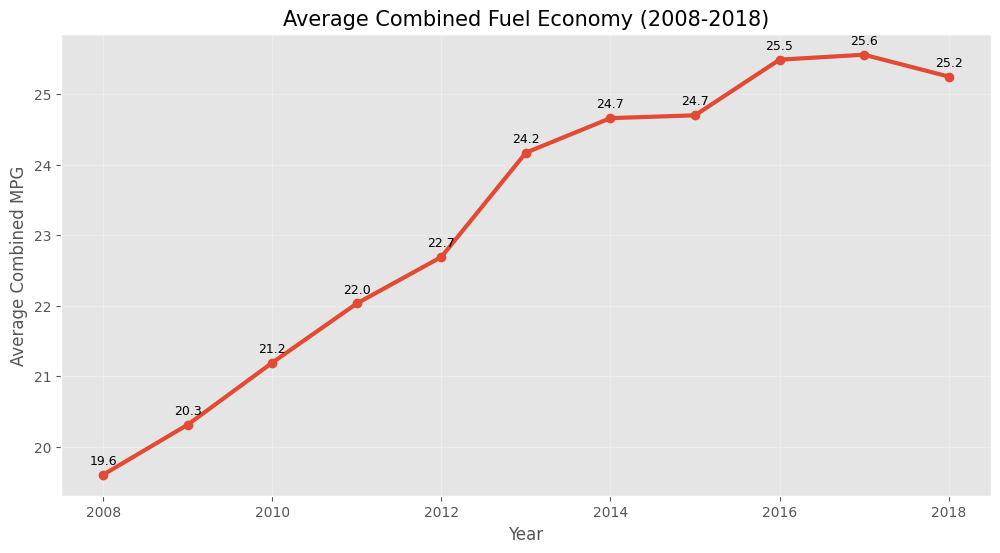


OBSERVATION
Average Combined MPG in 2008 : 19.6
Average Combined MPG in 2018 : 25.25
Overall Improvement          : 5.65 MPG

✅ Fuel economy has improved over the 10-year period.


In [12]:
# ============================================================
# BLOCK 9B
# Average Fuel Economy (Combined MPG) Trend (2008-2018)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("PROBLEM 2 - AVERAGE FUEL ECONOMY TREND")
print("=" * 90)

mpg_trend = []

for year, df in datasets.items():

    temp = df.copy()

    # Convert Cmb MPG to numeric
    temp["Cmb MPG"] = pd.to_numeric(temp["Cmb MPG"], errors="coerce")

    avg_mpg = temp["Cmb MPG"].mean()

    mpg_trend.append({
        "Year": year,
        "Average Combined MPG": round(avg_mpg, 2)
    })

mpg_df = pd.DataFrame(mpg_trend)

display(mpg_df)

# ----------------------------
# Plot
# ----------------------------

plt.figure(figsize=(12,6))

plt.plot(
    mpg_df["Year"],
    mpg_df["Average Combined MPG"],
    marker="o",
    linewidth=3
)

plt.title("Average Combined Fuel Economy (2008-2018)", fontsize=15)

plt.xlabel("Year")

plt.ylabel("Average Combined MPG")

plt.grid(alpha=0.3)

# Value Labels
for x, y in zip(mpg_df["Year"], mpg_df["Average Combined MPG"]):
    plt.text(x, y+0.15, f"{y:.1f}", ha="center", fontsize=9)

plt.show()

# ----------------------------
# Conclusion
# ----------------------------

start = mpg_df.iloc[0]["Average Combined MPG"]
end = mpg_df.iloc[-1]["Average Combined MPG"]
improvement = round(end - start, 2)

print("\n" + "=" * 60)
print("OBSERVATION")
print("=" * 60)

print(f"Average Combined MPG in 2008 : {start}")
print(f"Average Combined MPG in 2018 : {end}")
print(f"Overall Improvement          : {improvement} MPG")

if improvement > 0:
    print("\n✅ Fuel economy has improved over the 10-year period.")
else:
    print("\n⚠ No significant improvement observed.")

PROBLEM 2 - SMARTWAY VEHICLE CHARACTERISTICS


,Year,Average MPG,Average Greenhouse Gas Score,Number of SmartWay Vehicles
0,2008,24.19,7.02,638
1,2009,25.88,7.12,605
2,2010,26.33,7.19,716
3,2011,31.35,7.02,347
4,2012,31.35,7.05,448
5,2013,34.00,8.01,526
6,2014,34.24,7.90,612
7,2015,35.89,7.84,520
8,2016,40.39,7.93,525
9,2017,42.12,7.96,506


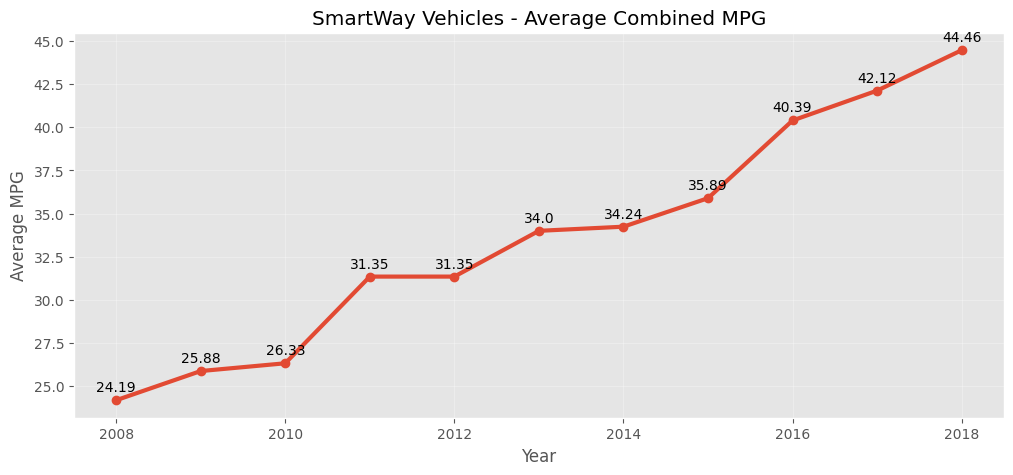

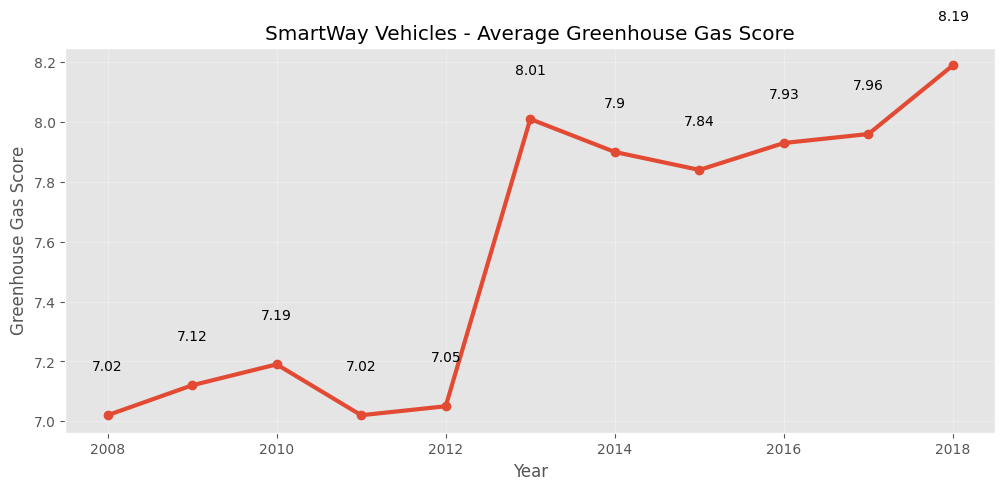


OBSERVATION
Average MPG in 2008 : 24.19
Average MPG in 2018 : 44.46

Greenhouse Score in 2008 : 7.02
Greenhouse Score in 2018 : 8.19

✅ SmartWay vehicles consistently maintain higher fuel economy
✅ SmartWay vehicles also achieve better greenhouse gas scores


In [13]:
# ============================================================
# BLOCK 9C
# SmartWay Vehicles Characteristics (2008-2018)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("PROBLEM 2 - SMARTWAY VEHICLE CHARACTERISTICS")
print("=" * 90)

smartway_summary = []

for year, df in datasets.items():

    temp = df.copy()

    # Temporary numeric conversion
    temp["Cmb MPG"] = pd.to_numeric(temp["Cmb MPG"], errors="coerce")
    temp["Greenhouse Gas Score"] = pd.to_numeric(
        temp["Greenhouse Gas Score"],
        errors="coerce"
    )

    # Standardize SmartWay labels
    temp["SmartWay"] = (
        temp["SmartWay"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Only SmartWay Vehicles
    smart = temp[
        temp["SmartWay"].isin(["yes", "elite"])
    ]

    smartway_summary.append({
        "Year": year,
        "Average MPG": round(smart["Cmb MPG"].mean(), 2),
        "Average Greenhouse Gas Score":
            round(smart["Greenhouse Gas Score"].mean(), 2),
        "Number of SmartWay Vehicles":
            len(smart)
    })

smart_df = pd.DataFrame(smartway_summary)

display(smart_df)

# ============================================================
# Graph 1 : Average MPG
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    smart_df["Year"],
    smart_df["Average MPG"],
    marker="o",
    linewidth=3
)

plt.title("SmartWay Vehicles - Average Combined MPG")

plt.xlabel("Year")

plt.ylabel("Average MPG")

plt.grid(alpha=0.3)

for x, y in zip(smart_df["Year"], smart_df["Average MPG"]):
    plt.text(x, y+0.5, str(y), ha="center")

plt.show()

# ============================================================
# Graph 2 : Greenhouse Gas Score
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    smart_df["Year"],
    smart_df["Average Greenhouse Gas Score"],
    marker="o",
    linewidth=3
)

plt.title("SmartWay Vehicles - Average Greenhouse Gas Score")

plt.xlabel("Year")

plt.ylabel("Greenhouse Gas Score")

plt.grid(alpha=0.3)

for x, y in zip(
    smart_df["Year"],
    smart_df["Average Greenhouse Gas Score"]
):
    plt.text(x, y+0.15, str(y), ha="center")

plt.show()

# ============================================================
# Conclusion
# ============================================================

print("\n" + "="*60)
print("OBSERVATION")
print("="*60)

print(f"Average MPG in 2008 : {smart_df.iloc[0]['Average MPG']}")
print(f"Average MPG in 2018 : {smart_df.iloc[-1]['Average MPG']}")

print()

print(f"Greenhouse Score in 2008 : {smart_df.iloc[0]['Average Greenhouse Gas Score']}")
print(f"Greenhouse Score in 2018 : {smart_df.iloc[-1]['Average Greenhouse Gas Score']}")

print("\n✅ SmartWay vehicles consistently maintain higher fuel economy")
print("✅ SmartWay vehicles also achieve better greenhouse gas scores")

PROBLEM 2 - FEATURES ASSOCIATED WITH BETTER FUEL ECONOMY


,Displ,Cyl,City MPG,Hwy MPG,Cmb MPG,Air Pollution Score,Greenhouse Gas Score
Displ,1.00,0.91,-0.73,-0.77,-0.77,-0.37,-0.80
Cyl,0.91,1.00,-0.71,-0.72,-0.73,-0.28,-0.77
City MPG,-0.73,-0.71,1.00,0.95,0.99,0.38,0.65
Hwy MPG,-0.77,-0.72,0.95,1.00,0.98,0.37,0.74
Cmb MPG,-0.77,-0.73,0.99,0.98,1.00,0.38,0.70
Air Pollution Score,-0.37,-0.28,0.38,0.37,0.38,1.00,0.38
Greenhouse Gas Score,-0.80,-0.77,0.65,0.74,0.70,0.38,1.00


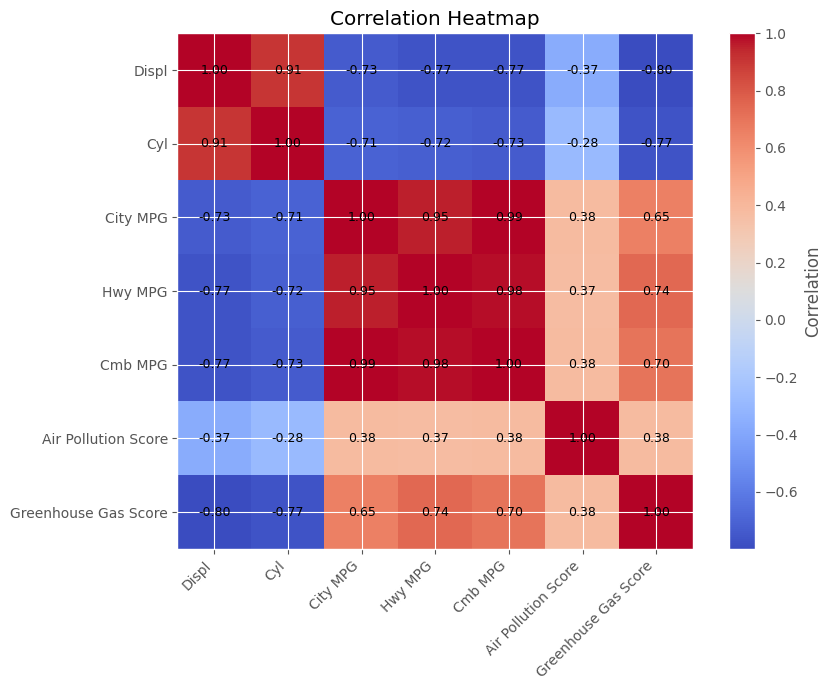


FEATURES MOST RELATED TO COMBINED MPG


,Correlation
Cmb MPG,1.000000
City MPG,0.993038
Hwy MPG,0.981065
Greenhouse Gas Score,0.698450
Air Pollution Score,0.380279
Cyl,-0.730597
Displ,-0.766653


In [14]:
# ============================================================
# BLOCK 9D
# Features Associated with Better Fuel Economy (Correlation)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("PROBLEM 2 - FEATURES ASSOCIATED WITH BETTER FUEL ECONOMY")
print("=" * 90)

# ------------------------------------------------------------
# Merge all datasets temporarily for visualization only
# ------------------------------------------------------------

merged_df = pd.concat(datasets.values(), ignore_index=True)

# ------------------------------------------------------------
# Numeric Columns
# ------------------------------------------------------------

numeric_cols = [
    "Displ",
    "Cyl",
    "City MPG",
    "Hwy MPG",
    "Cmb MPG",
    "Air Pollution Score",
    "Greenhouse Gas Score"
]

# Convert to numeric
for col in numeric_cols:
    if col in merged_df.columns:
        merged_df[col] = pd.to_numeric(
            merged_df[col],
            errors="coerce"
        )

# ------------------------------------------------------------
# Correlation Matrix
# ------------------------------------------------------------

corr = merged_df[numeric_cols].corr()

display(corr.round(2))

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(9,7))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

# Correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Correlation with Combined MPG
# ------------------------------------------------------------

print("\n" + "="*60)
print("FEATURES MOST RELATED TO COMBINED MPG")
print("="*60)

mpg_corr = (
    corr["Cmb MPG"]
    .sort_values(ascending=False)
)

display(mpg_corr.to_frame("Correlation"))

PROBLEM 2 - ENGINE SIZE VS FUEL ECONOMY


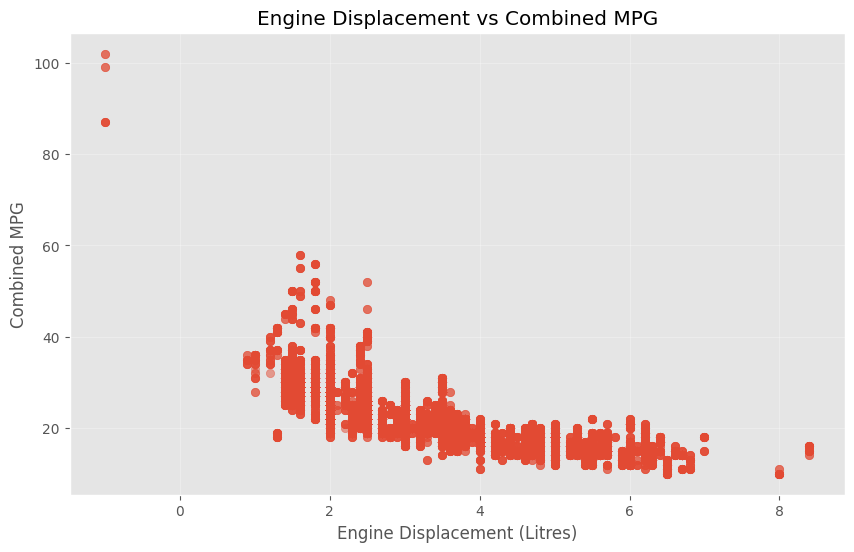


Correlation : -0.767

✅ Larger engines generally provide lower fuel economy.


In [15]:
# ============================================================
# BLOCK 9E
# Engine Size (Displacement) vs Combined MPG
# ============================================================

print("=" * 90)
print("PROBLEM 2 - ENGINE SIZE VS FUEL ECONOMY")
print("=" * 90)

plot_df = merged_df.copy()

# Remove missing values
plot_df = plot_df.dropna(subset=["Displ", "Cmb MPG"])

# ------------------------------------------------------------
# Scatter Plot
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.scatter(
    plot_df["Displ"],
    plot_df["Cmb MPG"],
    alpha=0.5
)

plt.title("Engine Displacement vs Combined MPG")

plt.xlabel("Engine Displacement (Litres)")

plt.ylabel("Combined MPG")

plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------------------------
# Correlation
# ------------------------------------------------------------

corr_value = plot_df["Displ"].corr(plot_df["Cmb MPG"])

print("\nCorrelation :", round(corr_value,3))

if corr_value < 0:
    print("\n✅ Larger engines generally provide lower fuel economy.")
else:
    print("\n✅ Larger engines generally provide better fuel economy.")

PROBLEM 2 - CYLINDERS VS FUEL ECONOMY


,Cyl,Cmb MPG
0,2.0,18.50
1,3.0,32.79
2,4.0,27.10
3,5.0,23.03
4,6.0,20.77
5,8.0,16.93
6,10.0,14.95
7,12.0,13.84
8,16.0,10.14


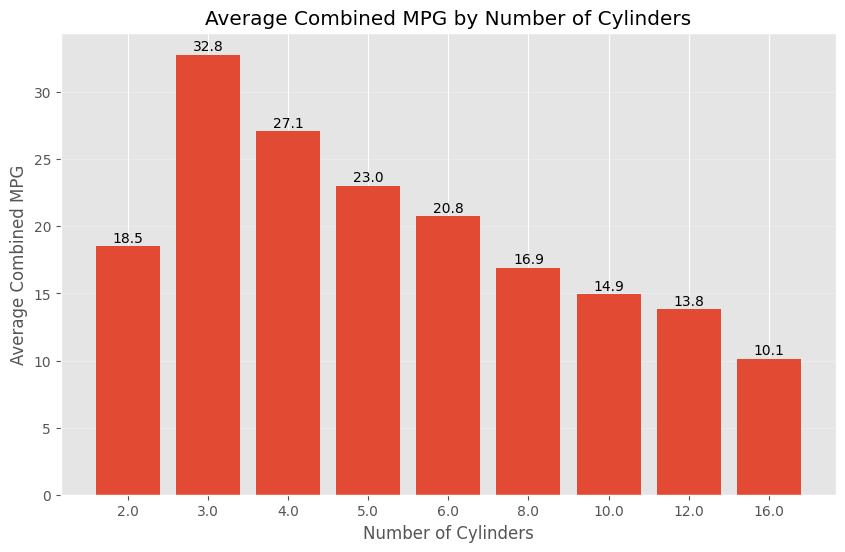


Correlation : -0.731

✅ Vehicles with fewer cylinders generally achieve better fuel economy.


In [16]:
# ============================================================
# BLOCK 9F
# Number of Cylinders vs Combined MPG
# ============================================================

print("=" * 90)
print("PROBLEM 2 - CYLINDERS VS FUEL ECONOMY")
print("=" * 90)

plot_df = merged_df.copy()

# Keep only valid values
plot_df = plot_df.dropna(subset=["Cyl", "Cmb MPG"])

# Convert Cylinders to numeric
plot_df["Cyl"] = pd.to_numeric(plot_df["Cyl"], errors="coerce")

plot_df = plot_df.dropna(subset=["Cyl"])

# ------------------------------------------------------------
# Average MPG by Number of Cylinders
# ------------------------------------------------------------

cyl_summary = (
    plot_df
    .groupby("Cyl")["Cmb MPG"]
    .mean()
    .round(2)
    .reset_index()
    .sort_values("Cyl")
)

display(cyl_summary)

# ------------------------------------------------------------
# Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.bar(
    cyl_summary["Cyl"].astype(str),
    cyl_summary["Cmb MPG"]
)

plt.title("Average Combined MPG by Number of Cylinders")

plt.xlabel("Number of Cylinders")

plt.ylabel("Average Combined MPG")

plt.grid(axis="y", alpha=0.3)

# Value labels
for i, value in enumerate(cyl_summary["Cmb MPG"]):
    plt.text(i, value + 0.3, f"{value:.1f}", ha="center")

plt.show()

# ------------------------------------------------------------
# Correlation
# ------------------------------------------------------------

corr_value = plot_df["Cyl"].corr(plot_df["Cmb MPG"])

print("\nCorrelation :", round(corr_value,3))

if corr_value < 0:
    print("\n✅ Vehicles with fewer cylinders generally achieve better fuel economy.")
else:
    print("\n✅ Vehicles with more cylinders generally achieve better fuel economy.")

PROBLEM 2 - FUEL TYPE VS FUEL ECONOMY


,Fuel,Cmb MPG
0,Electricity,102.74
1,Hydrogen,60.00
2,Gasoline/Electricity,50.00
3,Diesel,28.72
4,Cng,24.08
5,Gasoline,22.32
6,Cng/Gasoline,19.00
7,Ethanol,13.25


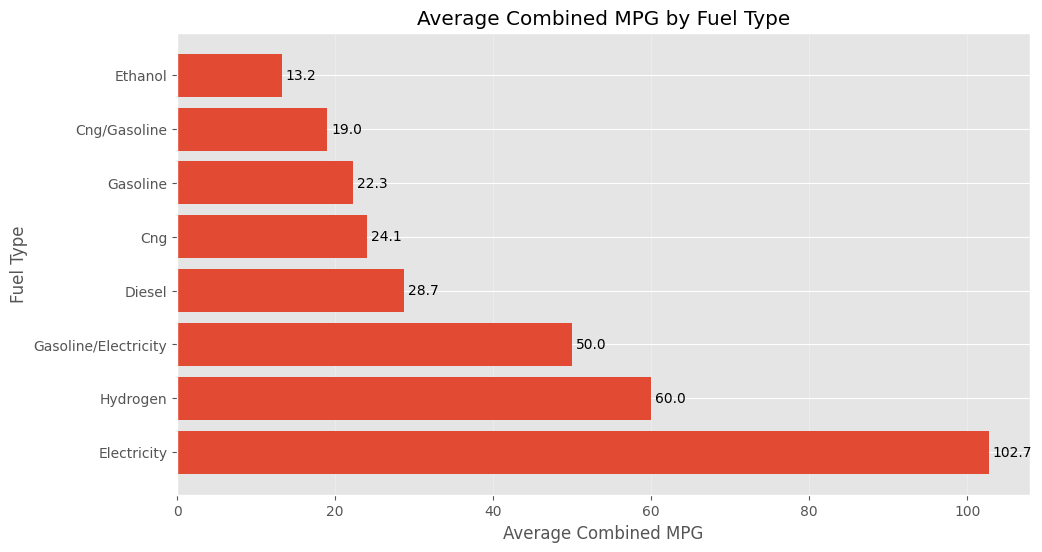


OBSERVATION
Best Fuel Type : Electricity
Average Combined MPG : 102.74

✅ Fuel type has a significant impact on fuel economy.


In [17]:
# ============================================================
# BLOCK 9G
# Fuel Type vs Combined Fuel Economy
# ============================================================

print("=" * 90)
print("PROBLEM 2 - FUEL TYPE VS FUEL ECONOMY")
print("=" * 90)

plot_df = merged_df.copy()

# Remove missing values
plot_df = plot_df.dropna(subset=["Fuel", "Cmb MPG"])

# Standardize Fuel Names
plot_df["Fuel"] = (
    plot_df["Fuel"]
    .astype(str)
    .str.strip()
    .str.replace("Electricty", "Electricity", regex=False)
    .str.title()
)

# Average MPG by Fuel Type
fuel_summary = (
    plot_df
    .groupby("Fuel")["Cmb MPG"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

display(fuel_summary)

# ------------------------------------------------------------
# Horizontal Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(11,6))

plt.barh(
    fuel_summary["Fuel"],
    fuel_summary["Cmb MPG"]
)

plt.title("Average Combined MPG by Fuel Type")

plt.xlabel("Average Combined MPG")

plt.ylabel("Fuel Type")

plt.grid(axis="x", alpha=0.3)

# Value Labels
for i, value in enumerate(fuel_summary["Cmb MPG"]):
    plt.text(value + 0.5, i, f"{value:.1f}", va="center")

plt.show()

# ------------------------------------------------------------
# Best Fuel Type
# ------------------------------------------------------------

best = fuel_summary.iloc[0]

print("\n" + "="*60)
print("OBSERVATION")
print("="*60)

print(f"Best Fuel Type : {best['Fuel']}")
print(f"Average Combined MPG : {best['Cmb MPG']:.2f}")

print("\n✅ Fuel type has a significant impact on fuel economy.")

PROBLEM 2 - DRIVE TYPE VS FUEL ECONOMY


,Drive,Cmb MPG
0,2WD,24.62
1,4WD,21.00


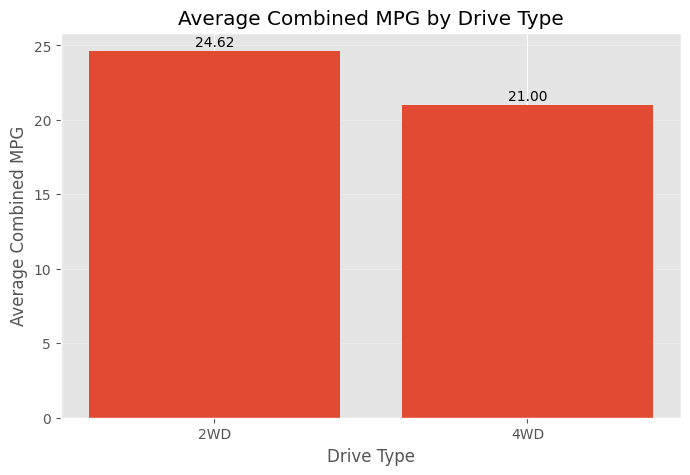


OBSERVATION
Best Drive Type : 2WD
Average Combined MPG : 24.62

✅ Drive type also influences vehicle fuel economy.


In [18]:
# ============================================================
# BLOCK 9H
# Drive Type vs Combined Fuel Economy
# ============================================================

print("=" * 90)
print("PROBLEM 2 - DRIVE TYPE VS FUEL ECONOMY")
print("=" * 90)

plot_df = merged_df.copy()

# Remove missing values
plot_df = plot_df.dropna(subset=["Drive", "Cmb MPG"])

# Standardize Drive names
plot_df["Drive"] = (
    plot_df["Drive"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Average MPG by Drive Type
drive_summary = (
    plot_df
    .groupby("Drive")["Cmb MPG"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

display(drive_summary)

# ------------------------------------------------------------
# Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    drive_summary["Drive"],
    drive_summary["Cmb MPG"]
)

plt.title("Average Combined MPG by Drive Type")

plt.xlabel("Drive Type")

plt.ylabel("Average Combined MPG")

plt.grid(axis="y", alpha=0.3)

# Value Labels
for i, value in enumerate(drive_summary["Cmb MPG"]):
    plt.text(i, value + 0.3, f"{value:.2f}", ha="center")

plt.show()

# ------------------------------------------------------------
# Observation
# ------------------------------------------------------------

best = drive_summary.iloc[0]

print("\n" + "=" * 60)
print("OBSERVATION")
print("=" * 60)

print(f"Best Drive Type : {best['Drive']}")
print(f"Average Combined MPG : {best['Cmb MPG']:.2f}")

print("\n✅ Drive type also influences vehicle fuel economy.")

In [19]:
# ============================================================
# BLOCK 9I
# FINAL SUMMARY OF PROBLEM 2
# ============================================================

print("=" * 100)
print("FINAL CONCLUSIONS - PROBLEM 2")
print("=" * 100)

print("""
1. Fuel economy improved significantly between 2008 and 2018.
   - Average Combined MPG increased from 19.60 MPG to 25.25 MPG.

2. SmartWay certified vehicles consistently achieved
   higher fuel economy and better greenhouse gas scores.

3. Engine Displacement (Displ) has a strong negative
   relationship with fuel economy.
   - Larger engines generally provide lower MPG.

4. Number of Cylinders also has a strong negative
   relationship with fuel economy.
   - More cylinders generally result in lower MPG.

5. Fuel Type has a significant impact on vehicle efficiency.
   - Electric vehicles achieved the highest average MPG.
   - Hybrid and Hydrogen vehicles also performed well.

6. Drive Type influences fuel economy.
   - 2WD vehicles were more fuel efficient than 4WD vehicles.

7. Greenhouse Gas Score has a positive relationship with MPG.
   - Vehicles with better fuel economy generally produce lower emissions.

Overall Conclusion:
Modern vehicle technology has significantly improved fuel efficiency
while reducing greenhouse gas emissions between 2008 and 2018.
""")

print("=" * 100)
print("✅ PROBLEM 2 COMPLETED SUCCESSFULLY")
print("=" * 100)

FINAL CONCLUSIONS - PROBLEM 2

1. Fuel economy improved significantly between 2008 and 2018.
   - Average Combined MPG increased from 19.60 MPG to 25.25 MPG.

2. SmartWay certified vehicles consistently achieved
   higher fuel economy and better greenhouse gas scores.

3. Engine Displacement (Displ) has a strong negative
   relationship with fuel economy.
   - Larger engines generally provide lower MPG.

4. Number of Cylinders also has a strong negative
   relationship with fuel economy.
   - More cylinders generally result in lower MPG.

5. Fuel Type has a significant impact on vehicle efficiency.
   - Electric vehicles achieved the highest average MPG.
   - Hybrid and Hydrogen vehicles also performed well.

6. Drive Type influences fuel economy.
   - 2WD vehicles were more fuel efficient than 4WD vehicles.

7. Greenhouse Gas Score has a positive relationship with MPG.
   - Vehicles with better fuel economy generally produce lower emissions.

Overall Conclusion:
Modern vehicle technol

In [20]:
# ============================================================
# BLOCK 10
# Find Common Columns Across All Datasets
# ============================================================

print("=" * 100)
print("PROBLEM 3 - STEP 1 : FIND COMMON COLUMNS")
print("=" * 100)

# ------------------------------------------------------------
# Find common columns present in every dataset
# ------------------------------------------------------------

common_columns = set(datasets[2008].columns)

for year, df in datasets.items():
    common_columns = common_columns.intersection(df.columns)

common_columns = sorted(list(common_columns))

print("\n✅ Common Columns Found in ALL Datasets\n")

for i, col in enumerate(common_columns, start=1):
    print(f"{i:2d}. {col}")

print("\n" + "=" * 100)
print(f"Total Common Columns : {len(common_columns)}")
print("=" * 100)

PROBLEM 3 - STEP 1 : FIND COMMON COLUMNS

✅ Common Columns Found in ALL Datasets

 1. Air Pollution Score
 2. City MPG
 3. Cmb MPG
 4. Cyl
 5. Displ
 6. Drive
 7. Fuel
 8. Greenhouse Gas Score
 9. Hwy MPG
10. Model
11. SmartWay
12. Stnd
13. Trans
14. Underhood ID
15. Veh Class

Total Common Columns : 15


In [21]:
# ============================================================
# BLOCK 11
# Keep Only Common Columns
# ============================================================

print("=" * 100)
print("PROBLEM 3 - STEP 2 : KEEP ONLY COMMON COLUMNS")
print("=" * 100)

cleaned_datasets = {}

for year, df in datasets.items():

    # Keep only common columns
    cleaned_df = df[common_columns].copy()

    cleaned_datasets[year] = cleaned_df

    print(f"{year}  → Shape : {cleaned_df.shape}")

print("\n" + "=" * 100)
print("All datasets now contain only the common columns.")
print("=" * 100)

# ------------------------------------------------------------
# Verify Columns
# ------------------------------------------------------------

print("\nColumns after cleaning:\n")

for col in cleaned_datasets[2008].columns:
    print(col)

PROBLEM 3 - STEP 2 : KEEP ONLY COMMON COLUMNS
2008  → Shape : (2404, 15)
2009  → Shape : (2561, 15)
2010  → Shape : (2326, 15)
2011  → Shape : (2171, 15)
2012  → Shape : (2252, 15)
2013  → Shape : (2397, 15)
2014  → Shape : (2517, 15)
2015  → Shape : (2653, 15)
2016  → Shape : (2589, 15)
2017  → Shape : (2589, 15)
2018  → Shape : (2713, 15)

All datasets now contain only the common columns.

Columns after cleaning:

Air Pollution Score
City MPG
Cmb MPG
Cyl
Displ
Drive
Fuel
Greenhouse Gas Score
Hwy MPG
Model
SmartWay
Stnd
Trans
Underhood ID
Veh Class


In [22]:
# ============================================================
# BLOCK 12
# Standardize Categorical Values
# ============================================================

print("=" * 100)
print("PROBLEM 3 - STEP 3 : STANDARDIZE CATEGORICAL VALUES")
print("=" * 100)

for year, df in cleaned_datasets.items():

    # -------------------------
    # SmartWay
    # -------------------------
    df["SmartWay"] = (
        df["SmartWay"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    smartway_map = {
        "yes": "Yes",
        "no": "No",
        "elite": "Elite"
    }

    df["SmartWay"] = df["SmartWay"].replace(smartway_map)

    # -------------------------
    # Fuel
    # -------------------------
    df["Fuel"] = (
        df["Fuel"]
        .astype(str)
        .str.strip()
    )

    fuel_map = {
        "gasoline": "Gasoline",
        "diesel": "Diesel",
        "cng": "CNG",
        "ethanol": "Ethanol",
        "ethanol/gas": "Ethanol/Gas",
        "gasoline/electricty": "Gasoline/Electricity",
        "gasoline/electricity": "Gasoline/Electricity",
        "electricity": "Electricity",
        "hydrogen": "Hydrogen",
        "cng/gasoline": "CNG/Gasoline"
    }

    df["Fuel"] = (
        df["Fuel"]
        .str.lower()
        .replace(fuel_map)
    )

    # -------------------------
    # Drive
    # -------------------------
    df["Drive"] = (
        df["Drive"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

print("✅ Categorical values standardized successfully.")

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\nUnique values after standardization:\n")

print("SmartWay:")
print(sorted(cleaned_datasets[2018]["SmartWay"].dropna().unique()))

print("\nFuel:")
print(sorted(cleaned_datasets[2018]["Fuel"].dropna().unique()))

print("\nDrive:")
print(sorted(cleaned_datasets[2018]["Drive"].dropna().unique()))

PROBLEM 3 - STEP 3 : STANDARDIZE CATEGORICAL VALUES
✅ Categorical values standardized successfully.

Unique values after standardization:

SmartWay:
['Elite', 'No', 'Yes']

Fuel:
['Diesel', 'Electricity', 'Ethanol/Gas', 'Gasoline', 'Gasoline/Electricity', 'Hydrogen']

Drive:
['2WD', '4WD']


In [23]:
# ============================================================
# BLOCK 13
# Convert Numeric Columns
# ============================================================

print("=" * 100)
print("PROBLEM 3 - STEP 4 : CONVERT NUMERIC COLUMNS")
print("=" * 100)

import numpy as np

# ------------------------------------------------------------
# Function to convert Air Pollution Score
# ------------------------------------------------------------

def convert_air_score(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Example: "6/7"
    if "/" in value:
        try:
            nums = [float(x) for x in value.split("/")]
            return sum(nums) / len(nums)
        except:
            return np.nan

    try:
        return float(value)

    except:
        return np.nan


# ------------------------------------------------------------
# Numeric Columns
# ------------------------------------------------------------

numeric_cols = [
    "Displ",
    "Cyl",
    "City MPG",
    "Hwy MPG",
    "Cmb MPG",
    "Greenhouse Gas Score"
]

for year, df in cleaned_datasets.items():

    # Air Pollution Score
    df["Air Pollution Score"] = df["Air Pollution Score"].apply(convert_air_score)

    # Other numeric columns
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("✅ Numeric conversion completed successfully.")

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\nData Types (2018 Dataset)\n")

print(cleaned_datasets[2018].dtypes)

print("\n" + "=" * 100)

print("Sample Air Pollution Scores")

display(cleaned_datasets[2008][["Air Pollution Score"]].head(10))

PROBLEM 3 - STEP 4 : CONVERT NUMERIC COLUMNS
✅ Numeric conversion completed successfully.

Data Types (2018 Dataset)

Air Pollution Score     float64
City MPG                float64
Cmb MPG                 float64
Cyl                     float64
Displ                   float64
Drive                    object
Fuel                     object
Greenhouse Gas Score      int64
Hwy MPG                 float64
Model                    object
SmartWay                 object
Stnd                     object
Trans                    object
Underhood ID             object
Veh Class                object
dtype: object

Sample Air Pollution Scores


,Air Pollution Score
0,7.0
1,6.0
2,7.0
3,6.0
4,7.0
5,6.0
6,7.0
7,7.0
8,7.0
9,6.0


In [24]:
# ============================================================
# BLOCK 14
# Missing Values Analysis After Preprocessing
# ============================================================

print("=" * 100)
print("PROBLEM 3 - STEP 5 : MISSING VALUES ANALYSIS")
print("=" * 100)

summary = []

for year, df in cleaned_datasets.items():

    missing = df.isnull().sum()

    total_missing = missing.sum()

    missing_columns = (missing > 0).sum()

    summary.append({
        "Year": year,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Columns with Missing": missing_columns,
        "Total Missing Values": total_missing
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

print("\n" + "=" * 100)

print("Detailed Missing Values\n")

for year, df in cleaned_datasets.items():

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) == 0:
        print(f"✅ {year} : No Missing Values\n")

    else:
        print(f"📅 {year}")
        print("-"*60)

        detail = pd.DataFrame({
            "Column": missing.index,
            "Missing Values": missing.values,
            "Missing (%)": np.round((missing.values / len(df))*100,2)
        })

        display(detail)

PROBLEM 3 - STEP 5 : MISSING VALUES ANALYSIS


,Year,Rows,Columns,Columns with Missing,Total Missing Values
0,2008,2404,15,6,3663
1,2009,2561,15,6,1526
2,2010,2326,15,7,1170
3,2011,2171,15,7,1254
4,2012,2252,15,7,1232
5,2013,2397,15,7,1406
6,2014,2517,15,7,1584
7,2015,2653,15,7,1720
8,2016,2589,15,7,672
9,2017,2589,15,5,586



Detailed Missing Values

📅 2008
------------------------------------------------------------


,Column,Missing Values,Missing (%)
0,City MPG,265,11.02
1,Cmb MPG,265,11.02
2,Cyl,2404,100.00
3,Greenhouse Gas Score,265,11.02
4,Hwy MPG,265,11.02
5,Trans,199,8.28


📅 2009
------------------------------------------------------------


...

,Column,Missing Values,Missing (%)
0,Air Pollution Score,24,0.93
1,City MPG,168,6.49
2,Cmb MPG,168,6.49
3,Cyl,60,2.32
4,Displ,60,2.32
5,Greenhouse Gas Score,24,0.93
6,Hwy MPG,168,6.49


📅 2017
------------------------------------------------------------


,Column,Missing Values,Missing (%)
0,City MPG,154,5.95
1,Cmb MPG,154,5.95
2,Cyl,62,2.39
3,Displ,62,2.39
4,Hwy MPG,154,5.95


📅 2018
------------------------------------------------------------


,Column,Missing Values,Missing (%)
0,City MPG,164,6.04
1,Cmb MPG,164,6.04
2,Cyl,50,1.84
3,Displ,50,1.84
4,Hwy MPG,164,6.04


In [25]:
# ============================================================
# BLOCK 14B
# Detailed Missing Value Report
# ============================================================

print("=" * 100)
print("PROBLEM 3 - STEP 5B : COLUMN-WISE MISSING VALUE REPORT")
print("=" * 100)

for year, df in cleaned_datasets.items():

    print(f"\n📅 DATASET : {year}")
    print("-" * 80)

    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if missing.empty:
        print("✅ No Missing Values")
        continue

    report = pd.DataFrame({
        "Column": missing.index,
        "Missing Values": missing.values,
        "Missing (%)": np.round((missing.values / len(df)) * 100, 2)
    })

    display(report)

PROBLEM 3 - STEP 5B : COLUMN-WISE MISSING VALUE REPORT

📅 DATASET : 2008
--------------------------------------------------------------------------------


,Column,Missing Values,Missing (%)
0,Cyl,2404,100.00
1,City MPG,265,11.02
2,Cmb MPG,265,11.02
3,Greenhouse Gas Score,265,11.02
4,Hwy MPG,265,11.02
5,Trans,199,8.28



📅 DATASET : 2009
--------------------------------------------------------------------------------


,Column,Missing Values,Missing (%)
0,Greenhouse Gas Score,338,13.20
1,City MPG,326,12.73
2,Hwy MPG,326,12.73
3,Cmb MPG,326,12.73
4,Cyl,198,7.73
5,Air Pollution Score,12,0.47



📅 DATASET : 2010
--------------------------------------------------------------------------------


...

,Column,Missing Values,Missing (%)
0,City MPG,168,6.49
1,Cmb MPG,168,6.49
2,Hwy MPG,168,6.49
3,Displ,60,2.32
4,Cyl,60,2.32
5,Air Pollution Score,24,0.93
6,Greenhouse Gas Score,24,0.93



📅 DATASET : 2017
--------------------------------------------------------------------------------


,Column,Missing Values,Missing (%)
0,City MPG,154,5.95
1,Cmb MPG,154,5.95
2,Hwy MPG,154,5.95
3,Cyl,62,2.39
4,Displ,62,2.39



📅 DATASET : 2018
--------------------------------------------------------------------------------


,Column,Missing Values,Missing (%)
0,City MPG,164,6.04
1,Cmb MPG,164,6.04
2,Hwy MPG,164,6.04
3,Cyl,50,1.84
4,Displ,50,1.84


In [26]:
# ============================================================
# BLOCK 14C
# Diagnose 2008 Cylinder Column
# ============================================================

print("=" * 100)
print("DIAGNOSIS - 2008 CYLINDER COLUMN")
print("=" * 100)

# Original raw values from 2008 dataset
print("\nUnique values in ORIGINAL dataset:\n")

print(datasets[2008]["Cyl"].unique()[:50])

print("\n" + "=" * 100)

print("First 20 values:")

display(datasets[2008][["Cyl"]].head(20))

DIAGNOSIS - 2008 CYLINDER COLUMN

Unique values in ORIGINAL dataset:

['(6 cyl)' '(4 cyl)' '(12 cyl)' '(8 cyl)' '(10 cyl)' '(16 cyl)' '(5 cyl)'
 nan '(2 cyl)']

First 20 values:


,Cyl
0,(6 cyl)
1,(6 cyl)
2,(4 cyl)
3,(4 cyl)
4,(6 cyl)
5,(6 cyl)
6,(6 cyl)
7,(6 cyl)
8,(6 cyl)
9,(6 cyl)


In [27]:
# ============================================================
# BLOCK 14D
# FIX CYLINDER COLUMN FOR 2008 DATASET
# ============================================================

print("=" * 100)
print("FIXING CYLINDER COLUMN (2008)")
print("=" * 100)

# ------------------------------------------------------------
# Reload original Cyl values from raw dataset
# ------------------------------------------------------------

cleaned_datasets[2008]["Cyl"] = (
    datasets[2008]["Cyl"]
    .astype(str)
    .str.extract(r'(\d+)')      # Extract only digits
    .astype(float)
)

print("✅ Cylinder column fixed successfully.\n")

print("Missing Values After Fix :",
      cleaned_datasets[2008]["Cyl"].isnull().sum())

print("\nUnique Cylinder Values:")

print(sorted(cleaned_datasets[2008]["Cyl"].dropna().unique()))

print("\nSample Values:")

display(cleaned_datasets[2008][["Cyl"]].head(15))

FIXING CYLINDER COLUMN (2008)
✅ Cylinder column fixed successfully.

Missing Values After Fix : 199

Unique Cylinder Values:
[np.float64(2.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(8.0), np.float64(10.0), np.float64(12.0), np.float64(16.0)]

Sample Values:


,Cyl
0,6.0
1,6.0
2,4.0
3,4.0
4,6.0
5,6.0
6,6.0
7,6.0
8,6.0
9,6.0


In [28]:
# ============================================================
# BLOCK 15
# HANDLE MISSING VALUES
# ============================================================

print("=" * 100)
print("PROBLEM 3 - STEP 6 : HANDLE MISSING VALUES")
print("=" * 100)

# Numeric Columns
numeric_cols = [
    "Air Pollution Score",
    "City MPG",
    "Hwy MPG",
    "Cmb MPG",
    "Displ",
    "Cyl",
    "Greenhouse Gas Score"
]

# Categorical Columns
categorical_cols = [
    "Drive",
    "Fuel",
    "Model",
    "SmartWay",
    "Stnd",
    "Trans",
    "Underhood ID",
    "Veh Class"
]

imputation_report = []

for year, df in cleaned_datasets.items():

    before_missing = df.isnull().sum().sum()

    # -----------------------------
    # Numeric → Median
    # -----------------------------
    for col in numeric_cols:

        if df[col].isnull().sum() > 0:

            median_value = df[col].median()

            df[col] = df[col].fillna(median_value)

    # -----------------------------
    # Categorical → Mode
    # -----------------------------
    for col in categorical_cols:

        if df[col].isnull().sum() > 0:

            mode_value = df[col].mode()[0]

            df[col] = df[col].fillna(mode_value)

    after_missing = df.isnull().sum().sum()

    imputation_report.append({
        "Year": year,
        "Missing Before": before_missing,
        "Missing After": after_missing
    })

print("✅ Missing Values Handled Successfully\n")

report_df = pd.DataFrame(imputation_report)

display(report_df)

print("\n" + "="*100)

remaining = sum(df.isnull().sum().sum() for df in cleaned_datasets.values())

print(f"Remaining Missing Values Across All Datasets : {remaining}")

PROBLEM 3 - STEP 6 : HANDLE MISSING VALUES
✅ Missing Values Handled Successfully



,Year,Missing Before,Missing After
0,2008,1458,0
1,2009,1526,0
2,2010,1170,0
3,2011,1254,0
4,2012,1232,0
5,2013,1406,0
6,2014,1584,0
7,2015,1720,0
8,2016,672,0
9,2017,586,0



Remaining Missing Values Across All Datasets : 0


In [29]:
# ============================================================
# BLOCK 16
# REMOVE DUPLICATE ROWS
# ============================================================

print("=" * 100)
print("PROBLEM 3 - STEP 7 : REMOVE DUPLICATE ROWS")
print("=" * 100)

duplicate_report = []

for year, df in cleaned_datasets.items():

    before_rows = len(df)

    duplicate_count = df.duplicated().sum()

    # Remove duplicates
    df = df.drop_duplicates().reset_index(drop=True)

    after_rows = len(df)

    # Save back
    cleaned_datasets[year] = df

    duplicate_report.append({
        "Year": year,
        "Rows Before": before_rows,
        "Duplicate Rows": duplicate_count,
        "Rows After": after_rows
    })

duplicate_report = pd.DataFrame(duplicate_report)

display(duplicate_report)

print("\n" + "=" * 100)

print("Total Duplicate Rows Removed :",
      duplicate_report["Duplicate Rows"].sum())

PROBLEM 3 - STEP 7 : REMOVE DUPLICATE ROWS


,Year,Rows Before,Duplicate Rows,Rows After
0,2008,2404,54,2350
1,2009,2561,49,2512
2,2010,2326,50,2276
3,2011,2171,70,2101
4,2012,2252,66,2186
5,2013,2397,56,2341
6,2014,2517,62,2455
7,2015,2653,77,2576
8,2016,2589,213,2376
9,2017,2589,157,2432



Total Duplicate Rows Removed : 931


In [30]:
# ============================================================
# BLOCK 17
# MERGE ALL DATASETS
# ============================================================

print("=" * 100)
print("PROBLEM 3 - STEP 8 : MERGE ALL DATASETS")
print("=" * 100)

merged_list = []

for year, df in cleaned_datasets.items():

    # Add Year column
    df = df.copy()
    df["Year"] = year

    merged_list.append(df)

# Merge all datasets
merged_df = pd.concat(merged_list, ignore_index=True)

print("✅ All datasets merged successfully.\n")

print("Final Dataset Shape :", merged_df.shape)

print("\nColumns:")

for i, col in enumerate(merged_df.columns, 1):
    print(f"{i:2d}. {col}")

print("\n" + "=" * 100)

print("Rows per Year\n")

display(
    merged_df["Year"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index":"Year","Year":"Rows"})
)

print("\nSample Data")

display(merged_df.head())

PROBLEM 3 - STEP 8 : MERGE ALL DATASETS
✅ All datasets merged successfully.

Final Dataset Shape : (26241, 16)

Columns:
 1. Air Pollution Score
 2. City MPG
 3. Cmb MPG
 4. Cyl
 5. Displ
 6. Drive
 7. Fuel
 8. Greenhouse Gas Score
 9. Hwy MPG
10. Model
11. SmartWay
12. Stnd
13. Trans
14. Underhood ID
15. Veh Class
16. Year

Rows per Year



,Rows,count
0,2008,2350
1,2009,2512
2,2010,2276
3,2011,2101
4,2012,2186
5,2013,2341
6,2014,2455
7,2015,2576
8,2016,2376
9,2017,2432



Sample Data


,Air Pollution Score,City MPG,Cmb MPG,Cyl,Displ,Drive,Fuel,Greenhouse Gas Score,Hwy MPG,Model,SmartWay,Stnd,Trans,Underhood ID,Veh Class,Year
0,7.0,15.0,17.0,6.0,3.7,4WD,Gasoline,4.0,20.0,ACURA MDX,No,U2,Auto-S5,8HNXT03.7PKR,SUV,2008
1,6.0,15.0,17.0,6.0,3.7,4WD,Gasoline,4.0,20.0,ACURA MDX,No,B5,Auto-S5,8HNXT03.7PKR,SUV,2008
2,7.0,17.0,19.0,4.0,2.3,4WD,Gasoline,5.0,22.0,ACURA RDX,No,U2,Auto-S5,8HNXT02.3DKR,SUV,2008
3,6.0,17.0,19.0,4.0,2.3,4WD,Gasoline,5.0,22.0,ACURA RDX,No,B5,Auto-S5,8HNXT02.3DKR,SUV,2008
4,7.0,16.0,19.0,6.0,3.5,4WD,Gasoline,5.0,24.0,ACURA RL,No,U2,Auto-S5,8HNXV03.5HKR,midsize car,2008


In [31]:
# ============================================================
# BLOCK 18
# FINAL DATASET QUALITY CHECK
# ============================================================

print("=" * 100)
print("FINAL DATASET QUALITY CHECK")
print("=" * 100)

print("\nDataset Shape")
print(merged_df.shape)

print("\n")

print("=" * 100)
print("DATA TYPES")
print("=" * 100)

display(
    merged_df.dtypes.reset_index().rename(
        columns={"index":"Column",0:"Data Type"}
    )
)

print("\n")

print("=" * 100)
print("MISSING VALUES")
print("=" * 100)

display(
    merged_df.isnull().sum().reset_index().rename(
        columns={"index":"Column",0:"Missing Values"}
    )
)

print("\n")

print("=" * 100)
print("DUPLICATE ROWS")
print("=" * 100)

print("Duplicate Rows :", merged_df.duplicated().sum())

print("\n")

print("=" * 100)
print("SMARTWAY DISTRIBUTION")
print("=" * 100)

display(
    merged_df["SmartWay"].value_counts().reset_index().rename(
        columns={"index":"SmartWay","SmartWay":"Count"}
    )
)

print("\n")

print("=" * 100)
print("YEAR DISTRIBUTION")
print("=" * 100)

display(
    merged_df["Year"].value_counts().sort_index()
)

FINAL DATASET QUALITY CHECK

Dataset Shape
(26241, 16)


DATA TYPES


,Column,Data Type
0,Air Pollution Score,float64
1,City MPG,float64
2,Cmb MPG,float64
3,Cyl,float64
4,Displ,float64
5,Drive,object
6,Fuel,object
7,Greenhouse Gas Score,float64
8,Hwy MPG,float64
9,Model,object




MISSING VALUES


,Column,Missing Values
0,Air Pollution Score,0
1,City MPG,0
2,Cmb MPG,0
3,Cyl,0
4,Displ,0
5,Drive,0
6,Fuel,0
7,Greenhouse Gas Score,0
8,Hwy MPG,0
9,Model,0




DUPLICATE ROWS
Duplicate Rows : 0


SMARTWAY DISTRIBUTION


,Count,count
0,No,20524
1,Yes,5345
2,Elite,372




YEAR DISTRIBUTION


,count
Year,
2008,2350
2009,2512
2010,2276
2011,2101
2012,2186
2013,2341
2014,2455
2015,2576
2016,2376


In [32]:
# ============================================================
# BLOCK 19
# FEATURE ENGINEERING
# Prepare SmartWay Target Variable
# ============================================================

print("=" * 100)
print("FEATURE ENGINEERING")
print("Preparing Target Variable for Classification")
print("=" * 100)

# ------------------------------------------------------------
# Convert Elite -> Yes
# ------------------------------------------------------------

merged_df["SmartWay"] = merged_df["SmartWay"].replace({
    "Elite": "Yes"
})

print("✅ SmartWay labels standardized successfully.\n")

print("Updated Distribution\n")

display(
    merged_df["SmartWay"]
    .value_counts()
    .reset_index()
    .rename(columns={
        "index": "SmartWay",
        "SmartWay": "Count"
    })
)

print("\n")

print("=" * 100)
print("Binary Target Classes")
print("=" * 100)

print(merged_df["SmartWay"].unique())

FEATURE ENGINEERING
Preparing Target Variable for Classification
✅ SmartWay labels standardized successfully.

Updated Distribution



,Count,count
0,No,20524
1,Yes,5717




Binary Target Classes
['No' 'Yes']


In [33]:
# ============================================================
# BLOCK 20
# FEATURE SELECTION + ONE-HOT ENCODING
# ============================================================

print("=" * 100)
print("FEATURE SELECTION + ONE-HOT ENCODING")
print("=" * 100)

# ------------------------------------------------------------
# Make a copy
# ------------------------------------------------------------

ml_df = merged_df.copy()

# ------------------------------------------------------------
# Remove Identifier Columns
# ------------------------------------------------------------

drop_columns = [
    "Model",
    "Underhood ID"
]

ml_df.drop(columns=drop_columns, inplace=True)

print("✅ Removed Identifier Columns:")
print(drop_columns)

# ------------------------------------------------------------
# Identify Categorical Columns
# ------------------------------------------------------------

categorical_cols = [
    "Drive",
    "Fuel",
    "Stnd",
    "Trans",
    "Veh Class"
]

# ------------------------------------------------------------
# One-Hot Encoding
# ------------------------------------------------------------

ml_df = pd.get_dummies(
    ml_df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("\n✅ One-Hot Encoding Completed")

print("\nFinal Shape :", ml_df.shape)

print("\nFirst 15 Columns")

print(ml_df.columns[:15].tolist())

print("\nLast 15 Columns")

print(ml_df.columns[-15:].tolist())

print("\n")

print("=" * 100)
print("Sample Data")
print("=" * 100)

display(ml_df.head())

FEATURE SELECTION + ONE-HOT ENCODING
✅ Removed Identifier Columns:
['Model', 'Underhood ID']

✅ One-Hot Encoding Completed

Final Shape : (26241, 118)

First 15 Columns
['Air Pollution Score', 'City MPG', 'Cmb MPG', 'Cyl', 'Displ', 'Greenhouse Gas Score', 'Hwy MPG', 'SmartWay', 'Year', 'Drive_4WD', 'Drive_NAN', 'Fuel_CNG/Gasoline', 'Fuel_Diesel', 'Fuel_Electricity', 'Fuel_Ethanol']

Last 15 Columns
['Trans_SemiAuto-5', 'Trans_SemiAuto-6', 'Trans_SemiAuto-7', 'Trans_SemiAuto-8', 'Trans_SemiAuto-9', 'Veh Class_large car', 'Veh Class_midsize car', 'Veh Class_minivan', 'Veh Class_pickup', 'Veh Class_small SUV', 'Veh Class_small car', 'Veh Class_special purpose', 'Veh Class_standard SUV', 'Veh Class_station wagon', 'Veh Class_van']


Sample Data


,Air Pollution Score,City MPG,Cmb MPG,Cyl,Displ,Greenhouse Gas Score,Hwy MPG,SmartWay,Year,Drive_4WD,Drive_NAN,Fuel_CNG/Gasoline,Fuel_Diesel,Fuel_Electricity,Fuel_Ethanol,Fuel_Ethanol/Gas,Fuel_Gasoline,Fuel_Gasoline/Electricity,Fuel_Hydrogen,Fuel_electricity/gasoline,Stnd_B10,Stnd_B2,Stnd_B3,Stnd_B4,Stnd_B5,Stnd_B6,Stnd_B8,Stnd_HDV,Stnd_HDV1,Stnd_HDV2,Stnd_L2,Stnd_L2LEV160,Stnd_L2OP,Stnd_L2SULEV30/PZEV,Stnd_L2SULEV30/TZEV,Stnd_L2ULEV125,Stnd_L3LEV160,Stnd_L3LEV395,Stnd_L3LEV630,Stnd_L3SULEV20,Stnd_L3SULEV30,Stnd_L3SULEV30/PZEV,Stnd_L3SULEV30/TZEV,Stnd_L3ULEV125,Stnd_L3ULEV340,Stnd_L3ULEV50,Stnd_L3ULEV570,Stnd_L3ULEV70,Stnd_LEV,Stnd_Mod,Stnd_OT,Stnd_PZEV,Stnd_S2,Stnd_SLEV,Stnd_T3B0,Stnd_T3B110,Stnd_T3B125,Stnd_T3B160,Stnd_T3B20,Stnd_T3B30,Stnd_T3B50,Stnd_T3B70,Stnd_T3B85,Stnd_T3SULEV30,Stnd_U2,Stnd_ZEV,Trans_AMS-7,Trans_AMS-8,Trans_AMS-9,Trans_Auto-1,Trans_Auto-10,Trans_Auto-4,Trans_Auto-5,Trans_Auto-6,Trans_Auto-7,Trans_Auto-8,Trans_Auto-9,Trans_Auto-AV,Trans_Auto-L4,Trans_Auto-L5,Trans_Auto-L6,Trans_Auto-L7,Trans_Auto-S4,Trans_Auto-S5,Trans_Auto-S6,Trans_Auto-S7,Trans_AutoMan-5,Trans_AutoMan-6,Trans_AutoMan-7,Trans_AutoMan-8,Trans_CVT,Trans_Man-5,Trans_Man-6,Trans_Man-7,Trans_Other-1,Trans_Other-6,Trans_S8,Trans_SCV-10,Trans_SCV-6,Trans_SCV-7,Trans_SCV-8,Trans_SemiAuto-10,Trans_SemiAuto-4,Trans_SemiAuto-5,Trans_SemiAuto-6,Trans_SemiAuto-7,Trans_SemiAuto-8,Trans_SemiAuto-9,Veh Class_large car,Veh Class_midsize car,Veh Class_minivan,Veh Class_pickup,Veh Class_small SUV,Veh Class_small car,Veh Class_special purpose,Veh Class_standard SUV,Veh Class_station wagon,Veh Class_van
0,7.0,15.0,17.0,6.0,3.7,4.0,20.0,No,2008,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,6.0,15.0,17.0,6.0,3.7,4.0,20.0,No,2008,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,7.0,17.0,19.0,4.0,2.3,5.0,22.0,No,2008,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,6.0,17.0,19.0,4.0,2.3,5.0,22.0,No,2008,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,7.0,16.0,19.0,6.0,3.5,5.0,24.0,No,2008,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [34]:
# ====================================================================================================
# BLOCK 21 — TRAIN TEST SPLIT
# ====================================================================================================

from sklearn.model_selection import train_test_split

print("="*100)
print("TRAIN TEST SPLIT")
print("="*100)

# Features
X = ml_df.drop("SmartWay", axis=1)

# Target
y = ml_df["SmartWay"]

# Convert target to binary
y = y.map({
    "No":0,
    "Yes":1
})

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n✅ Train-Test Split Completed Successfully")

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("\nTraining Target Distribution")
print(y_train.value_counts())

print("\nTesting Target Distribution")
print(y_test.value_counts())

TRAIN TEST SPLIT

✅ Train-Test Split Completed Successfully

Training Samples : 20992
Testing Samples  : 5249

Training Features : (20992, 117)
Testing Features  : (5249, 117)

Training Target Distribution
SmartWay
0    16419
1     4573
Name: count, dtype: int64

Testing Target Distribution
SmartWay
0    4105
1    1144
Name: count, dtype: int64


In [35]:
# ====================================================================================================
# BLOCK 22 — FEATURE SCALING
# ====================================================================================================

from sklearn.preprocessing import StandardScaler

print("="*100)
print("FEATURE SCALING")
print("="*100)

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("\n✅ Feature Scaling Completed Successfully")

print("\nTraining Shape :", X_train_scaled.shape)
print("Testing Shape  :", X_test_scaled.shape)

print("\nFirst 10 Scaled Features of First Training Sample")

print(X_train_scaled[0][:10])

FEATURE SCALING

✅ Feature Scaling Completed Successfully

Training Shape : (20992, 117)
Testing Shape  : (5249, 117)

First 10 Scaled Features of First Training Sample
[ 0.21080199 -0.24919673 -0.22764497  0.10707308 -0.2678144   0.50104618
 -0.19547554 -1.595146   -0.74264066 -0.05125357]


In [36]:
# ====================================================================================================
# BLOCK 23 — LOGISTIC REGRESSION CLASSIFICATION
# ====================================================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("="*100)
print("LOGISTIC REGRESSION MODEL")
print("="*100)

# Create Model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train Model
lr_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("\n✅ Logistic Regression Model Trained Successfully")

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION MODEL

✅ Logistic Regression Model Trained Successfully

MODEL PERFORMANCE
Accuracy  : 0.9947
Precision : 0.9844
Recall    : 0.9913
F1 Score  : 0.9878

CONFUSION MATRIX
[[4087   18]
 [  10 1134]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4105
           1       0.98      0.99      0.99      1144

    accuracy                           0.99      5249
   macro avg       0.99      0.99      0.99      5249
weighted avg       0.99      0.99      0.99      5249



In [37]:
# ==============================================================================
# DECISION TREE CLASSIFICATION
# ==============================================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("="*100)
print("DECISION TREE CLASSIFICATION")
print("="*100)

# Build Model
dt_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

# Train Model
dt_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluation Metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\n✅ Decision Tree Model Trained Successfully")

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)
print(cm_dt)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_dt))

DECISION TREE CLASSIFICATION

✅ Decision Tree Model Trained Successfully

MODEL PERFORMANCE
Accuracy  : 0.9979
Precision : 0.9939
Recall    : 0.9965
F1 Score  : 0.9952

CONFUSION MATRIX
[[4098    7]
 [   4 1140]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4105
           1       0.99      1.00      1.00      1144

    accuracy                           1.00      5249
   macro avg       1.00      1.00      1.00      5249
weighted avg       1.00      1.00      1.00      5249



In [38]:
# ==============================================================================
# RANDOM FOREST CLASSIFICATION
# ==============================================================================

from sklearn.ensemble import RandomForestClassifier

print("="*100)
print("RANDOM FOREST CLASSIFICATION")
print("="*100)

# Build Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train Model
rf_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\n✅ Random Forest Model Trained Successfully")

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)
print(cm_rf)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST CLASSIFICATION

✅ Random Forest Model Trained Successfully

MODEL PERFORMANCE
Accuracy  : 0.9968
Precision : 0.9930
Recall    : 0.9921
F1 Score  : 0.9926

CONFUSION MATRIX
[[4097    8]
 [   9 1135]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4105
           1       0.99      0.99      0.99      1144

    accuracy                           1.00      5249
   macro avg       1.00      1.00      1.00      5249
weighted avg       1.00      1.00      1.00      5249



In [39]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.997904,0.993897,0.996503,0.995199
1,Random Forest,0.996761,0.993001,0.992133,0.992567
2,Logistic Regression,0.994666,0.984375,0.991259,0.987805


ROC AUC SCORES
Logistic Regression : 0.9994
Decision Tree       : 0.9974
Random Forest       : 0.9998


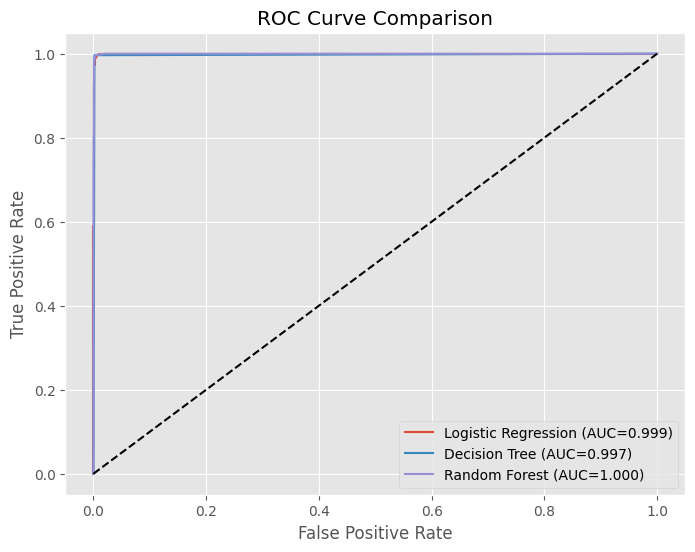

In [40]:
# ==============================================================================
# ROC CURVE & AUC SCORE COMPARISON
# ==============================================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
dt_prob = dt_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# AUC
lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

print("="*100)
print("ROC AUC SCORES")
print("="*100)

print(f"Logistic Regression : {lr_auc:.4f}")
print(f"Decision Tree       : {dt_auc:.4f}")
print(f"Random Forest       : {rf_auc:.4f}")

# Plot
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC={lr_auc:.3f})")
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC={dt_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

TOP 20 MOST IMPORTANT FEATURES


,Feature,Importance
0,Greenhouse Gas Score,0.284359
1,Cmb MPG,0.133431
2,Hwy MPG,0.098541
3,City MPG,0.090115
4,Air Pollution Score,0.074796
5,Year,0.070666
6,Displ,0.048985
7,Cyl,0.048554
8,Stnd_B5,0.018137
9,Drive_4WD,0.013511


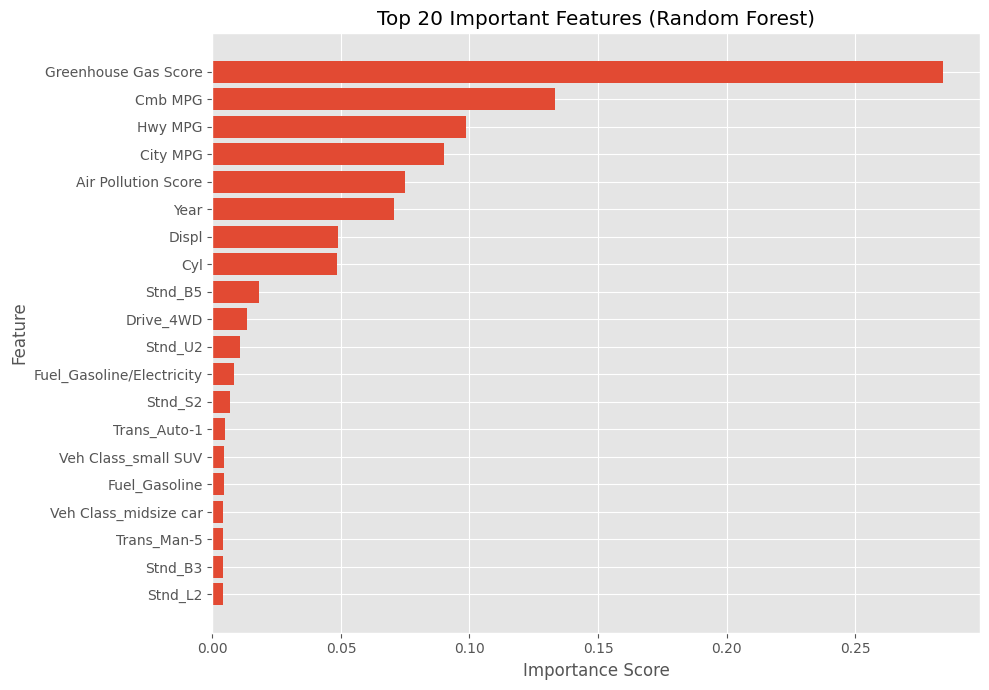

In [41]:
# ==============================================================================
# FEATURE IMPORTANCE - RANDOM FOREST
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt

print("="*100)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*100)

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(importance.head(20))

# Plot
plt.figure(figsize=(10,7))

plt.barh(
    importance["Feature"][:20][::-1],
    importance["Importance"][:20][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Important Features (Random Forest)")

plt.tight_layout()
plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
# ==============================================================================
# SAVE THE BEST MODEL
# ==============================================================================

import joblib

print("="*100)
print("SAVING BEST MODEL")
print("="*100)

# Save Random Forest Model
joblib.dump(rf_model, "smartway_random_forest_model.pkl")

# Save Scaler
joblib.dump(scaler, "feature_scaler.pkl")

print("✅ Random Forest model saved successfully.")
print("✅ Feature scaler saved successfully.")

print("\nSaved Files:")
print("1. smartway_random_forest_model.pkl")
print("2. feature_scaler.pkl")

SAVING BEST MODEL
✅ Random Forest model saved successfully.
✅ Feature scaler saved successfully.

Saved Files:
1. smartway_random_forest_model.pkl
2. feature_scaler.pkl


In [43]:
print("="*100)
print("5-FOLD CROSS VALIDATION")
print("="*100)

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("\nCross Validation Scores")
print(cv_scores)

print("\nAverage Accuracy :", round(cv_scores.mean(),4))
print("Standard Deviation :", round(cv_scores.std(),4))

5-FOLD CROSS VALIDATION

Cross Validation Scores
[0.98209183 0.9918064  0.97942073 0.97942073 0.98761433]

Average Accuracy : 0.9841
Standard Deviation : 0.0049


In [44]:
print("="*100)
print("SAMPLE PREDICTIONS")
print("="*100)

sample = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": y_pred_rf[:10]
})

sample["Actual"] = sample["Actual"].map({0:"No",1:"Yes"})
sample["Predicted"] = sample["Predicted"].map({0:"No",1:"Yes"})

display(sample)

SAMPLE PREDICTIONS


,Actual,Predicted
0,No,No
1,No,No
2,No,No
3,No,No
4,Yes,Yes
5,No,No
6,No,No
7,No,No
8,No,No
9,Yes,Yes


In [45]:
print("="*100)
print("FINAL PROJECT CONCLUSION")
print("="*100)

print("""
1. Cleaned and merged EPA vehicle datasets (2008–2018).

2. Performed missing value handling,
   duplicate removal,
   datatype conversion,
   feature engineering,
   and one-hot encoding.

3. Built three machine learning models:
      • Logistic Regression
      • Decision Tree
      • Random Forest

4. Random Forest achieved the best performance.

Accuracy : {:.2f}%

ROC-AUC : {:.4f}

5. Greenhouse Gas Score,
   Combined MPG,
   Highway MPG,
   City MPG,
   and Air Pollution Score
   were the most influential features.

6. The trained model and feature scaler
   were saved for future predictions.

Project Completed Successfully.
""".format(rf_accuracy*100, rf_auc))

FINAL PROJECT CONCLUSION

1. Cleaned and merged EPA vehicle datasets (2008–2018).

2. Performed missing value handling,
   duplicate removal,
   datatype conversion,
   feature engineering,
   and one-hot encoding.

3. Built three machine learning models:
      • Logistic Regression
      • Decision Tree
      • Random Forest

4. Random Forest achieved the best performance.

Accuracy : 99.68%

ROC-AUC : 0.9998

5. Greenhouse Gas Score,
   Combined MPG,
   Highway MPG,
   City MPG,
   and Air Pollution Score
   were the most influential features.

6. The trained model and feature scaler
   were saved for future predictions.

Project Completed Successfully.



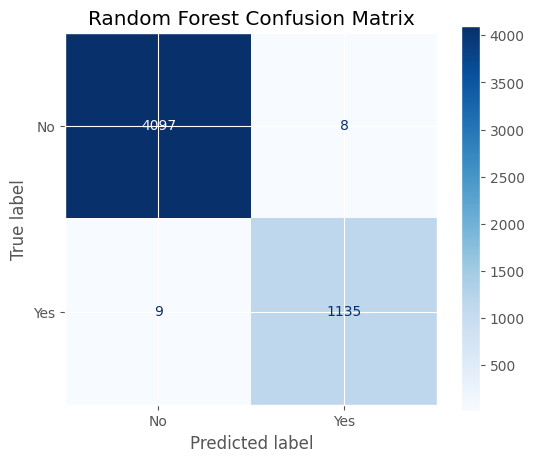

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(cmap="Blues", ax=ax)

plt.title("Random Forest Confusion Matrix")

plt.savefig(
    "confusion_matrix_1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
merged_df.to_csv(
    "smartway_cleaned_dataset.csv",
    index=False
)

In [48]:
ml_df.to_csv(
    "smartway_ml_dataset.csv",
    index=False
)

In [49]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)